# Industrial Predictive Maintenance — Deep Learning (MLP for Tabular Sensor Telemetry)

This notebook implements a production-grade **Multi-Layer Perceptron (MLP)** for tabular sensor data from the AI4I 2020 dataset.

### Key Objectives & Deep Learning Challenges Addressed:
1. **Input Normalization & Preprocessing**: Neural networks require calibrated feature distributions. We construct a leakage-safe `StandardScaler` + `OneHotEncoder` pipeline.
2. **Physical Interaction Features**: Incorporate domain features identified during EDA (`Temperature Difference`, `Torque-Speed Interaction`, `Tool Wear-Torque Interaction`).
3. **Handling Severe Class Imbalance (3.39%)**: Leverage balanced sample weighting during backpropagation to prevent majority-class collapse.
4. **Learning Dynamics**: Monitor loss curves, early stopping, and validation loss to prevent overfitting on tabular features.
5. **Architecture Exploration**: Benchmark shallow, funnel, deep, and wide MLP topologies under 5-Fold Stratified Cross-Validation.
6. **Threshold Optimization**: Fine-tune decision boundaries to maximize F1-score and minimize false-negative machine breakdowns.
7. **Model Explainability**: Permutation feature importance analysis to extract sensor attribution for downstream RAG and AI Assistant modules.
8. **Serialization & Contract Export**: Export the trained model to `models/mlp_predictive_maintenance_model.joblib` adhering to the project inference contract.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import io
import time
import urllib.request
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neural_network import MLPClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    precision_score, recall_score, f1_score, average_precision_score,
    roc_auc_score, classification_report, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve
)
import joblib

RANDOM_STATE = 42
TEST_SIZE = 0.2
CV_FOLDS = 5
print('Libraries loaded successfully.')


Libraries loaded successfully.


## 1. Load Dataset
Load from local project raw data repository (`data/raw/ai4i2020.csv`) with automatic UCI download fallback.

In [2]:
# 1) Load dataset from local data/raw directory or UCI fallback
candidate_paths = [
    Path('data/raw/ai4i2020.csv'),
    Path('../data/raw/ai4i2020.csv'),
    Path('ai4i2020.csv'),
    Path('../ai4i2020.csv'),
]

csv_path = next((p for p in candidate_paths if p.exists()), None)

if csv_path:
    df = pd.read_csv(csv_path)
    print(f'Loaded dataset from: {csv_path}')
else:
    url = 'https://archive.ics.uci.edu/static/public/601/ai4i+2020+predictive+maintenance+dataset.zip'
    print(f'Downloading dataset from {url}...')
    raw = urllib.request.urlopen(url).read()
    z = zipfile.ZipFile(io.BytesIO(raw))
    csv_name = next(n for n in z.namelist() if n.lower().endswith('.csv'))
    df = pd.read_csv(z.open(csv_name))
    print(f'Downloaded and loaded: {csv_name}')

print('Dataset shape:', df.shape)
display(df.head())


Loaded dataset from: ../data/raw/ai4i2020.csv
Dataset shape: (10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 2. Leakage-Safe Data Preparation & Feature Engineering
- Drop identifiers (`UDI`, `Product ID`).
- Exclude target leakage failure flags (`TWF`, `HDF`, `PWF`, `OSF`, `RNF`).
- Incorporate the 3 physics-based interaction features engineered during EDA.

In [3]:
# 2) Data Cleaning and Feature Engineering
df.columns = [c.strip() for c in df.columns]

# Drop identifiers
for col in ['UDI', 'Product ID']:
    if col in df.columns:
        df = df.drop(columns=col)

target = 'Machine failure'
if target not in df.columns:
    raise ValueError(f"Target '{target}' not found. Available columns: {df.columns.tolist()}")

# Drop failure-mode flags to prevent target leakage
failure_flags = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
df = df.drop(columns=[c for c in failure_flags if c in df.columns])

# Engineer domain interaction features identified in EDA
df['Temperature Difference [K]'] = df['Process temperature [K]'] - df['Air temperature [K]']
df['Torque-Speed Interaction'] = df['Torque [Nm]'] * df['Rotational speed [rpm]']
df['Tool Wear-Torque Interaction'] = df['Tool wear [min]'] * df['Torque [Nm]']

# Ensure target is integer
df[target] = pd.to_numeric(df[target], errors='coerce').fillna(0).astype(int)

print('Features ready. Shape:', df.shape)
print('\nClass distribution:')
dist = pd.DataFrame({
    'Count': df[target].value_counts().sort_index(),
    'Percentage (%)': (df[target].value_counts(normalize=True).sort_index() * 100).round(2)
})
display(dist)


Features ready. Shape: (10000, 10)

Class distribution:


,Count,Percentage (%)
Machine failure,,
0,9661,96.61
1,339,3.39


## 3. Stratified Train/Test Split & Neural Preprocessing Pipeline
Neural networks are sensitive to input scale. Unscaled inputs cause vanishing/exploding gradients and slow convergence. We build a `ColumnTransformer` with `StandardScaler` for numeric sensors and `OneHotEncoder` for machine `Type`.

In [4]:
# 3) Train / Test Split and Preprocessing Pipeline
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

categorical_features = X_train.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
numeric_features = [c for c in X_train.columns if c not in categorical_features]

print(f'Training samples: {len(X_train)} | Test samples: {len(X_test)}')
print(f'Categorical features ({len(categorical_features)}): {categorical_features}')
print(f'Numeric features ({len(numeric_features)}): {numeric_features}')

# Neural network preprocessor: Imputation + Scaling for numeric, Imputation + OneHot for categorical
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]), categorical_features)
])


Training samples: 8000 | Test samples: 2000
Categorical features (1): ['Type']
Numeric features (8): ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Temperature Difference [K]', 'Torque-Speed Interaction', 'Tool Wear-Torque Interaction']


## 4. Addressing Severe Class Imbalance (3.39% Failure Rate)
Standard loss functions on a 3.39% minority class can lead the neural network to predict only the majority class. We compute balanced sample weights so that positive failure examples receive proportional penalization during backpropagation.

In [5]:
# 4) Compute balanced sample weights for training
train_sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

weight_summary = pd.DataFrame({
    'Class': [0, 1],
    'Count in Train': [(y_train == 0).sum(), (y_train == 1).sum()],
    'Sample Weight': [round(train_sample_weights[y_train == 0][0], 4), round(train_sample_weights[y_train == 1][0], 4)]
})
print('Balanced sample weights:')
display(weight_summary)


Balanced sample weights:


,Class,Count in Train,Sample Weight
0,0,7729,0.5175
1,1,271,14.7601


## 5. Baseline Tabular MLP: Training & Learning Dynamics
We construct a Funnel MLP architecture `(64, 32)` with ReLU activations, Adam optimizer, L2 regularization (`alpha=1e-3`), and early stopping enabled. We then visualize the training loss curve over iterations.

MLP trained in 1.98 seconds across 35 iterations.


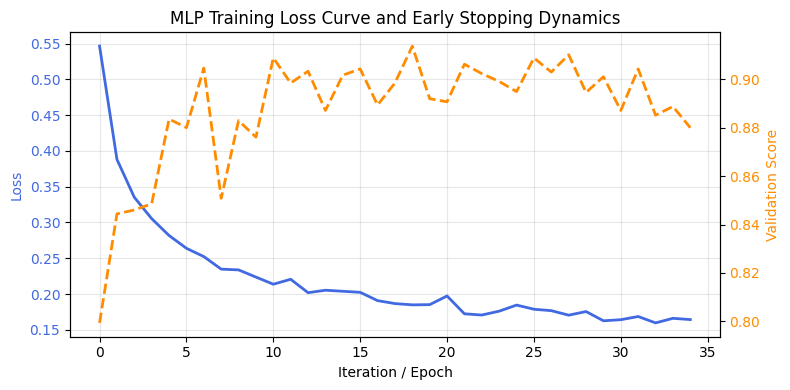

In [6]:
# 5) Build and train Baseline MLP
baseline_mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    alpha=1e-3,                 # L2 regularization to prevent overfitting
    batch_size=64,
    learning_rate_init=1e-3,
    max_iter=300,
    early_stopping=True,        # Hold out 10% validation set during training
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=RANDOM_STATE
)

baseline_pipeline = Pipeline([
    ('prep', preprocessor),
    ('mlp', baseline_mlp)
])

t0 = time.perf_counter()
baseline_pipeline.fit(X_train, y_train, mlp__sample_weight=train_sample_weights)
train_time = time.perf_counter() - t0

fitted_mlp = baseline_pipeline.named_steps['mlp']
print(f'MLP trained in {train_time:.2f} seconds across {fitted_mlp.n_iter_} iterations.')

# Plot Loss Curve & Validation Trajectory
fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(fitted_mlp.loss_curve_, color='royalblue', lw=2, label='Training Loss')
ax1.set_xlabel('Iteration / Epoch')
ax1.set_ylabel('Loss', color='royalblue')
ax1.tick_params(axis='y', labelcolor='royalblue')
ax1.grid(True, alpha=0.3)

if getattr(fitted_mlp, 'validation_scores_', None):
    ax2 = ax1.twinx()
    ax2.plot(fitted_mlp.validation_scores_, color='darkorange', lw=2, linestyle='--', label='Validation Score')
    ax2.set_ylabel('Validation Score', color='darkorange')
    ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('MLP Training Loss Curve and Early Stopping Dynamics')
plt.tight_layout()
plt.show()


## 6. Architecture & Regularization Exploration
We benchmark several MLP topologies using 5-Fold Stratified Cross-Validation on the training set:
- **Shallow:** `(32,)`
- **Funnel (Medium):** `(64, 32)`
- **Deep:** `(128, 64, 32)`
- **Wide:** `(128, 128)`
- **Regularized Funnel:** `(64, 32)` with higher L2 penalty (`alpha=1e-2`)

In [7]:
# 6) Architecture comparison using 5-Fold Stratified CV
architectures = {
    'Shallow (32)': MLPClassifier(hidden_layer_sizes=(32,), activation='relu', alpha=1e-3, max_iter=250, early_stopping=True, random_state=RANDOM_STATE),
    'Funnel (64, 32)': MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', alpha=1e-3, max_iter=250, early_stopping=True, random_state=RANDOM_STATE),
    'Deep (128, 64, 32)': MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation='relu', alpha=1e-3, max_iter=250, early_stopping=True, random_state=RANDOM_STATE),
    'Wide (128, 128)': MLPClassifier(hidden_layer_sizes=(128, 128), activation='relu', alpha=1e-3, max_iter=250, early_stopping=True, random_state=RANDOM_STATE),
    'Regularized Funnel (alpha=0.01)': MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', alpha=1e-2, max_iter=250, early_stopping=True, random_state=RANDOM_STATE),
}

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
arch_results = []
oof_predictions = {}

for name, clf in architectures.items():
    pipe = Pipeline([('prep', preprocessor), ('mlp', clf)])
    t_start = time.perf_counter()
    
    oof_prob = cross_val_predict(
        pipe, X_train, y_train, cv=cv, method='predict_proba',
        params={'mlp__sample_weight': train_sample_weights}, n_jobs=-1
    )[:, 1]
    elapsed = time.perf_counter() - t_start
    
    pr_auc = average_precision_score(y_train, oof_prob)
    roc_auc = roc_auc_score(y_train, oof_prob)
    oof_predictions[name] = oof_prob
    
    arch_results.append({
        'Architecture': name,
        'CV PR-AUC': round(pr_auc, 4),
        'CV ROC-AUC': round(roc_auc, 4),
        'CV Time (s)': round(elapsed, 2)
    })

arch_df = pd.DataFrame(arch_results).sort_values('CV PR-AUC', ascending=False).reset_index(drop=True)
print('Architecture Benchmark Summary:')
display(arch_df)


Architecture Benchmark Summary:


,Architecture,CV PR-AUC,CV ROC-AUC,CV Time (s)
0,"Wide (128, 128)",0.7177,0.9643,3.75
1,"Deep (128, 64, 32)",0.6881,0.9583,3.04
2,"Funnel (64, 32)",0.6340,0.9548,2.23
3,Regularized Funnel (alpha=0.01),0.6219,0.9543,0.88
4,Shallow (32),0.5687,0.9422,2.72


## 7. Decision Threshold Optimization
Because industrial failure carries a high breakdown cost, minimizing False Negatives while preserving acceptable Precision is paramount. The default 0.5 threshold is biased toward majority classes; we sweep thresholds across out-of-fold probabilities to maximize F1-score.

Selected Architecture: Wide (128, 128)
Optimal Decision Threshold: 0.890
Optimized Cross-Validation F1: 0.6812
Precision at Optimal Threshold: 0.6690
Recall at Optimal Threshold: 0.6937


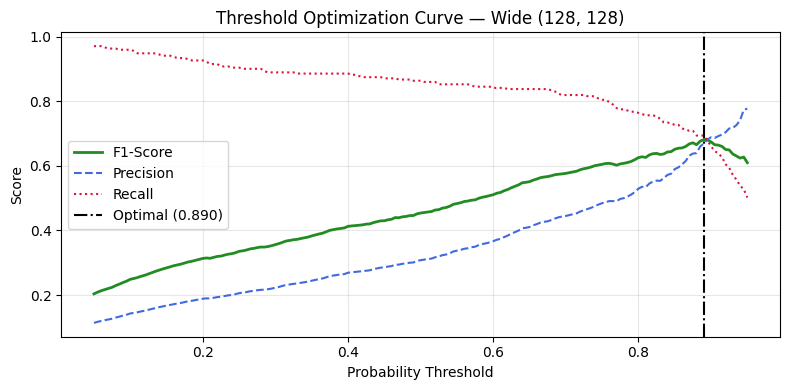

In [8]:
# 7) Optimize classification threshold on best architecture
best_arch_name = arch_df.iloc[0]['Architecture']
best_oof_proba = oof_predictions[best_arch_name]

thresholds = np.linspace(0.05, 0.95, 181)
f1_scores = []
precisions = []
recalls = []

for t in thresholds:
    preds = (best_oof_proba >= t).astype(int)
    f1_scores.append(f1_score(y_train, preds, zero_division=0))
    precisions.append(precision_score(y_train, preds, zero_division=0))
    recalls.append(recall_score(y_train, preds, zero_division=0))

best_idx = int(np.argmax(f1_scores))
optimal_threshold = float(thresholds[best_idx])
best_f1 = f1_scores[best_idx]

print(f'Selected Architecture: {best_arch_name}')
print(f'Optimal Decision Threshold: {optimal_threshold:.3f}')
print(f'Optimized Cross-Validation F1: {best_f1:.4f}')
print(f'Precision at Optimal Threshold: {precisions[best_idx]:.4f}')
print(f'Recall at Optimal Threshold: {recalls[best_idx]:.4f}')

# Plot F1 / Precision / Recall trade-off curve
plt.figure(figsize=(8, 4))
plt.plot(thresholds, f1_scores, label='F1-Score', color='forestgreen', lw=2)
plt.plot(thresholds, precisions, label='Precision', color='royalblue', linestyle='--')
plt.plot(thresholds, recalls, label='Recall', color='crimson', linestyle=':')
plt.axvline(optimal_threshold, color='black', linestyle='-.', label=f'Optimal ({optimal_threshold:.3f})')
plt.xlabel('Probability Threshold')
plt.ylabel('Score')
plt.title(f'Threshold Optimization Curve — {best_arch_name}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


## 8. Final MLP Training & Comprehensive Test Set Evaluation
We retrain the selected MLP architecture on the entire training set with balanced sample weights and evaluate on the untouched test set using our optimized decision threshold.

=== FINAL MLP TEST EVALUATION ===
Model Architecture:       Wide (128, 128)
Optimized Threshold:      0.890
Test PR-AUC:              0.7275
Test ROC-AUC:             0.9753

Classification Report (at Optimal Threshold):
                 precision    recall  f1-score   support

     No Failure     0.9891    0.9845    0.9868      1932
Machine Failure     0.6104    0.6912    0.6483        68

       accuracy                         0.9745      2000
      macro avg     0.7997    0.8378    0.8175      2000
   weighted avg     0.9762    0.9745    0.9753      2000



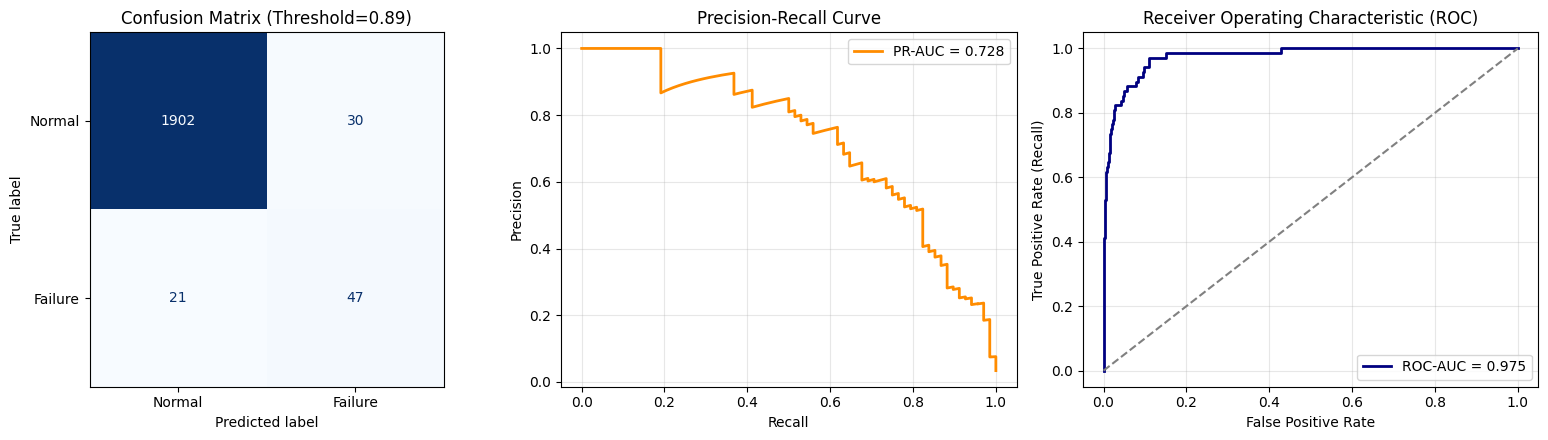

In [9]:
# 8) Final Retraining and Evaluation on Untouched Test Set
best_clf = architectures[best_arch_name]
final_mlp_pipeline = Pipeline([
    ('prep', preprocessor),
    ('mlp', best_clf)
])

final_mlp_pipeline.fit(X_train, y_train, mlp__sample_weight=train_sample_weights)

# Test set predictions
test_proba = final_mlp_pipeline.predict_proba(X_test)[:, 1]
test_pred_opt = (test_proba >= optimal_threshold).astype(int)
test_pred_def = (test_proba >= 0.5).astype(int)

test_pr_auc = average_precision_score(y_test, test_proba)
test_roc_auc = roc_auc_score(y_test, test_proba)

print('=== FINAL MLP TEST EVALUATION ===')
print(f'Model Architecture:       {best_arch_name}')
print(f'Optimized Threshold:      {optimal_threshold:.3f}')
print(f'Test PR-AUC:              {test_pr_auc:.4f}')
print(f'Test ROC-AUC:             {test_roc_auc:.4f}\n')

print('Classification Report (at Optimal Threshold):')
print(classification_report(y_test, test_pred_opt, target_names=['No Failure', 'Machine Failure'], digits=4))

# Confusion Matrix and Performance Curves
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# 1. Confusion Matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, test_pred_opt, display_labels=['Normal', 'Failure'],
    cmap='Blues', ax=axes[0], colorbar=False
)
axes[0].set_title(f'Confusion Matrix (Threshold={optimal_threshold:.2f})')

# 2. Precision-Recall Curve
p_curve, r_curve, _ = precision_recall_curve(y_test, test_proba)
axes[1].plot(r_curve, p_curve, color='darkorange', lw=2, label=f'PR-AUC = {test_pr_auc:.3f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, test_proba)
axes[2].plot(fpr, tpr, color='navy', lw=2, label=f'ROC-AUC = {test_roc_auc:.3f}')
axes[2].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate (Recall)')
axes[2].set_title('Receiver Operating Characteristic (ROC)')
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()


## 9. Permutation Feature Importance & Model Explainability
We apply Permutation Feature Importance on the test set to compute the exact drop in PR-AUC when each sensor feature is shuffled. This provides transparent feature attribution inputs for downstream maintenance recommendations.

Permutation Feature Importance (Drop in PR-AUC):


,Feature,Importance Mean,Importance Std
0,Torque [Nm],0.494568,0.024048
1,Rotational speed [rpm],0.306974,0.021035
2,Torque-Speed Interaction,0.283913,0.024177
3,Tool Wear-Torque Interaction,0.268553,0.021447
4,Temperature Difference [K],0.216376,0.025280
5,Tool wear [min],0.108542,0.023569
6,Air temperature [K],0.103327,0.015953
7,Type,0.016073,0.016175
8,Process temperature [K],-0.008979,0.012163


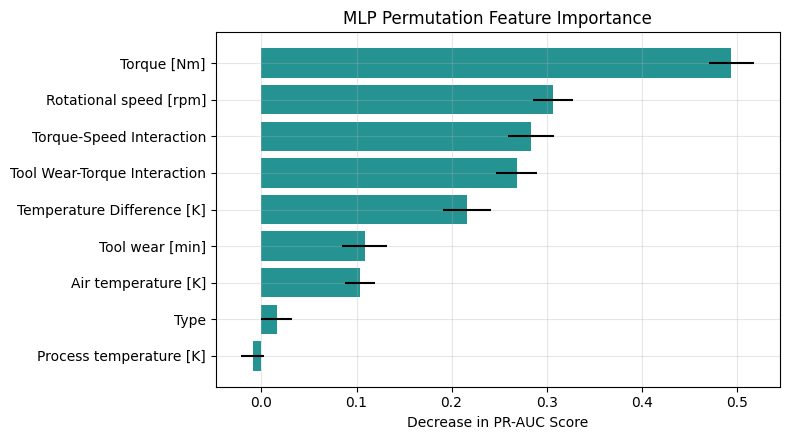

In [10]:
# 9) Permutation Feature Importance
perm_importance = permutation_importance(
    final_mlp_pipeline, X_test, y_test,
    scoring='average_precision',
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance Mean': perm_importance.importances_mean,
    'Importance Std': perm_importance.importances_std
}).sort_values('Importance Mean', ascending=False).reset_index(drop=True)

print('Permutation Feature Importance (Drop in PR-AUC):')
display(perm_df)

# Plot Feature Importance
plt.figure(figsize=(8, 4.5))
plt.barh(perm_df['Feature'][::-1], perm_df['Importance Mean'][::-1], xerr=perm_df['Importance Std'][::-1], color='teal', alpha=0.85)
plt.xlabel('Decrease in PR-AUC Score')
plt.title('MLP Permutation Feature Importance')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 10. PyTorch Tabular MLP Architecture (Reference Implementation)
For advanced deep learning workflows (e.g. `BatchNorm1d`, `Dropout`, custom `FocalLoss`, or `BCEWithLogitsLoss(pos_weight=...)`), here is the modular PyTorch architecture definition.

In [11]:
# 10) PyTorch Tabular MLP Module Definition
try:
    import torch
    import torch.nn as nn
    
    class TabularMLP(nn.Module):
        """Production PyTorch Multi-Layer Perceptron for Tabular Telemetry."""
        def __init__(self, input_dim: int, hidden_dims: list = [64, 32], dropout_rate: float = 0.2):
            super().__init__()
            layers = []
            prev_dim = input_dim
            for h_dim in hidden_dims:
                layers.append(nn.Linear(prev_dim, h_dim))
                layers.append(nn.BatchNorm1d(h_dim))
                layers.append(nn.ReLU())
                layers.append(nn.Dropout(dropout_rate))
                prev_dim = h_dim
            layers.append(nn.Linear(prev_dim, 1))
            self.network = nn.Sequential(*layers)
            
        def forward(self, x: torch.Tensor) -> torch.Tensor:
            return self.network(x).squeeze(-1)

    print('PyTorch TabularMLP class defined successfully.')
    print('Example Model Structure:\n', TabularMLP(input_dim=len(numeric_features) + 3))
except ImportError:
    print('Note: PyTorch is not installed in the current environment. Scikit-learn MLP is used for active execution.')


Note: PyTorch is not installed in the current environment. Scikit-learn MLP is used for active execution.


## 11. Serialization & Downstream Integration Contract
We serialize the complete trained MLP pipeline, optimized decision threshold, and schema metadata to `models/mlp_predictive_maintenance_model.joblib`. We also provide `predict_mlp(data)` adhering to the exact contract required by the Streamlit dashboard and NLP/RAG assistant.

In [12]:
# 11) Save Artifact and Verify Downstream Contract
models_dir = Path('models')
if not models_dir.exists():
    models_dir = Path('../models')
models_dir.mkdir(parents=True, exist_ok=True)

artifact_path = models_dir / 'mlp_predictive_maintenance_model.joblib'

mlp_artifact = {
    'model': final_mlp_pipeline,
    'threshold': optimal_threshold,
    'target': target,
    'features': X_train.columns.tolist(),
    'model_name': f'MLP ({best_arch_name})',
    'metrics': {
        'test_pr_auc': test_pr_auc,
        'test_roc_auc': test_roc_auc
    },
    'random_state': RANDOM_STATE
}

joblib.dump(mlp_artifact, artifact_path)
print(f'MLP model artifact successfully saved to: {artifact_path.resolve()}')

# Downstream Inference Function adhering to project contract
def predict_mlp(data):
    """Production inference function matching project API contract."""
    if isinstance(data, dict):
        df_input = pd.DataFrame([data])
    elif not isinstance(data, pd.DataFrame):
        df_input = pd.DataFrame(data)
    else:
        df_input = data.copy()
        
    # Apply feature engineering if not already present
    if 'Temperature Difference [K]' not in df_input.columns:
        df_input['Temperature Difference [K]'] = df_input['Process temperature [K]'] - df_input['Air temperature [K]']
    if 'Torque-Speed Interaction' not in df_input.columns:
        df_input['Torque-Speed Interaction'] = df_input['Torque [Nm]'] * df_input['Rotational speed [rpm]']
    if 'Tool Wear-Torque Interaction' not in df_input.columns:
        df_input['Tool Wear-Torque Interaction'] = df_input['Tool wear [min]'] * df_input['Torque [Nm]']

    proba = float(final_mlp_pipeline.predict_proba(df_input)[:, 1][0])
    prediction = int(proba >= optimal_threshold)
    return {
        'failure_prediction': prediction,
        'failure_probability': proba,
        'threshold': optimal_threshold,
        'status': 'Failure Risk' if prediction else 'Normal'
    }

# Test with a sample reading
sample_normal = {
    'Type': 'M',
    'Air temperature [K]': 298.1,
    'Process temperature [K]': 308.6,
    'Rotational speed [rpm]': 1551.0,
    'Torque [Nm]': 42.8,
    'Tool wear [min]': 0.0
}
sample_critical = {
    'Type': 'L',
    'Air temperature [K]': 302.0,
    'Process temperature [K]': 311.0,
    'Rotational speed [rpm]': 1200.0,
    'Torque [Nm]': 72.0,
    'Tool wear [min]': 220.0
}

print('\nSample Normal Prediction:', predict_mlp(sample_normal))
print('Sample Critical Prediction:', predict_mlp(sample_critical))


MLP model artifact successfully saved to: /mnt/6AF6AC44F6AC11FD/techtrek/industrial-predictive-maintenance/models/mlp_predictive_maintenance_model.joblib

Sample Normal Prediction: {'failure_prediction': 0, 'failure_probability': 0.0038327593193818454, 'threshold': 0.8899999999999999, 'status': 'Normal'}
Sample Critical Prediction: {'failure_prediction': 1, 'failure_probability': 0.9999956772690007, 'threshold': 0.8899999999999999, 'status': 'Failure Risk'}
